# Some plots to check the DINEOF run
The run has been done with the script run_dineof_2.sh in the /dineof-3.0 folder
Input : RHED and SEAL daily data from July 2019 to December 2021

- Number of EOF modes retained : 25
- Convergence level required : 0.1e-2

## EOF outputs

I am a bit worried about the EOF 2 (see annotation), because I think that it is where the spin comes from in the vector reconstruction. 

EOF 3 shows very ugly peaks when both radials are missing, and higher variability when one radial is missing :'( 

In [310]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 
import xarray as xr
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import warnings
from datetime import timedelta

get_ipython().run_line_magic('run', '"/media/nbourg/One Touch/PhD/Separation_HFR_EAC/toolbox.ipynb"')
warnings.filterwarnings('ignore')


path = '/media/nbourg/One Touch/PhD/Separation_HFR_EAC/Data_Processing/Gap_Filling/run_newcastle/'
rhed_pre = xr.open_dataset(path+'pre_post_processing/daily_2019_2021_RHED_pre.nc')
seal_pre = xr.open_dataset(path+'pre_post_processing/daily_2019_2021_SEAL_pre.nc')

sc_rhed_pre = get_spatial_coverage(rhed_pre['v'].values)
sc_seal_pre = get_spatial_coverage(seal_pre['v'].values)

rhed_filled = xr.open_dataset(path+'my_result_folder/log2/daily_2019_2021_RHED_din.nc')
seal_filled = xr.open_dataset(path+'my_result_folder/log2/daily_2019_2021_SEAL_din.nc')

rhed_mask = xr.open_dataset(path+'pre_post_processing/mask_2019_2021_RHED.nc')
seal_mask = xr.open_dataset(path+'pre_post_processing/mask_2019_2021_SEAL.nc')

yes_rhed = np.transpose(rhed_mask['mask'].values)
yes_rhed = yes_rhed[yes_rhed==1]

timeseries_eof = np.loadtxt(path+'my_result_folder/log2/outputEof.rghvec')
eof = np.loadtxt(path+'my_result_folder/log2/outputEof.lftvec')
eof_rhed_file = eof[:yes_rhed.shape[0],:]
eof_seal_file = eof[yes_rhed.shape[0]:,:]


eof_rhed = np.nan*np.zeros((rhed_mask['mask'].shape[1],rhed_mask['mask'].shape[0],eof.shape[1]))
eof_seal = np.nan*np.zeros((seal_mask['mask'].shape[1],seal_mask['mask'].shape[0],eof.shape[1]))

eof_rhed[np.transpose(rhed_mask['mask'].values)==1]=eof_rhed_file
eof_seal[np.transpose(seal_mask['mask'].values)==1]=eof_seal_file

pd_time=np.array([pd.datetime(2019,7,1)+timedelta(days=i) for i in range(1,timeseries_eof.shape[0]+1)])

Text(150, -32, 'Weird rotation?')

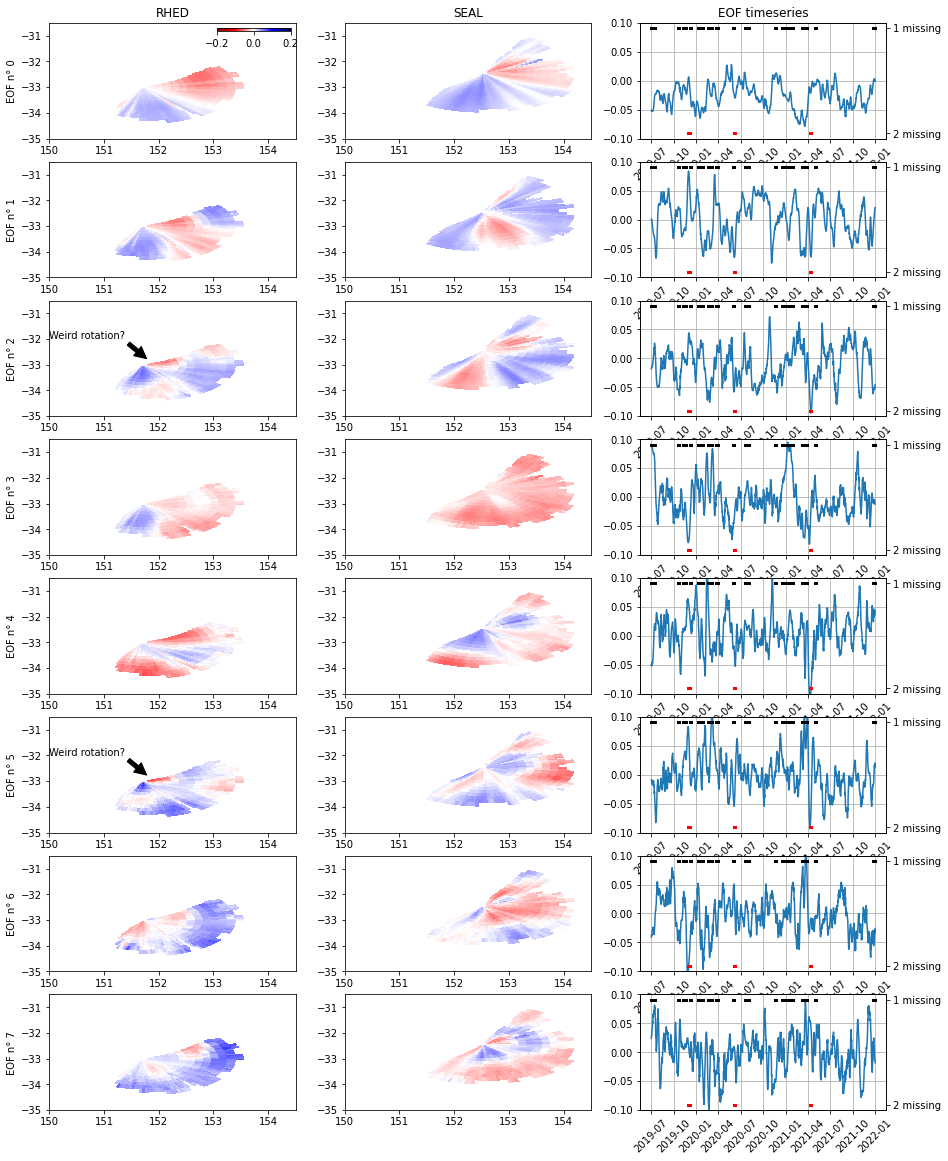

In [266]:
fig, axs = plt.subplots(ncols=3,nrows=8,figsize=(15,20))
for i in range(0,8):
    
    axs[i,0].pcolor(rhed_pre['lon'],rhed_pre['lat'],np.transpose(eof_rhed[:,:,i]),vmin=-0.2,vmax=.2,cmap='seismic_r')
    pc=axs[i,1].pcolor(seal_pre['lon'],seal_pre['lat'],np.transpose(eof_seal[:,:,i]),vmin=-0.2,vmax=.2,cmap='seismic_r')
    axs[i,2].set_ylim(-0.1,0.1)
    axs[i,0].set_ylim(-35,-30.5)
    axs[i,1].set_ylim(-35,-30.5)

    axs[i,0].set_xlim(150,154.5)
    axs[i,1].set_xlim(150,154.5)

    sp = axs[i,2].twinx()
    
    missing = np.nan*np.zeros(sc_rhed_pre.shape)
    missing[np.logical_and(sc_rhed_pre==0,sc_seal_pre==0)]=0
    
    missing_one = np.nan*np.zeros(sc_rhed_pre.shape)
    missing_one[np.logical_or(sc_rhed_pre==0,sc_seal_pre==0)]=1
    missing_one[missing==0]=np.nan
    
    sp.plot(pd_time,missing,c='r',linewidth=3,zorder=2)
    sp.plot(pd_time,missing_one,c='k',linewidth=3,zorder=2)
    sp.set_yticks([0,1])
    sp.set_yticklabels(['2 missing','1 missing'])
    axs[i,2].tick_params(axis='x', rotation=45)
    sp.tick_params(axis='x', rotation=45)

    axs[i,2].grid(zorder=0)
    axs[i,2].plot(pd_time,timeseries_eof[:,i],zorder=3)

    axs[i,0].set_ylabel('EOF n° '+str(i))

cbaxes = inset_axes(axs[0,0], width="30%", height="3%", loc=1)

fig.colorbar(pc,cax=cbaxes,orientation='horizontal')
axs[0,2].title.set_text('EOF timeseries')
axs[0,0].title.set_text('RHED')
axs[0,1].title.set_text('SEAL')


#ANNOTATIONS

axs[2,0].annotate('Weird rotation?', xy=(151.8, -32.8), xytext=(150, -32),
            arrowprops=dict(facecolor='black', shrink=0.05))


axs[5,0].annotate('Weird rotation?', xy=(151.8, -32.8), xytext=(150, -32),
            arrowprops=dict(facecolor='black', shrink=0.05))



----

## Comparing inputs & outputs

Seems like the filling is doing a lot of smoothing

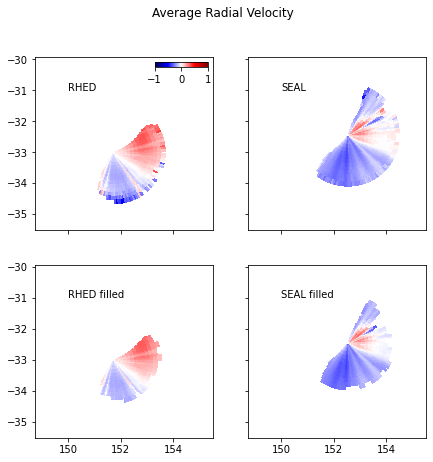

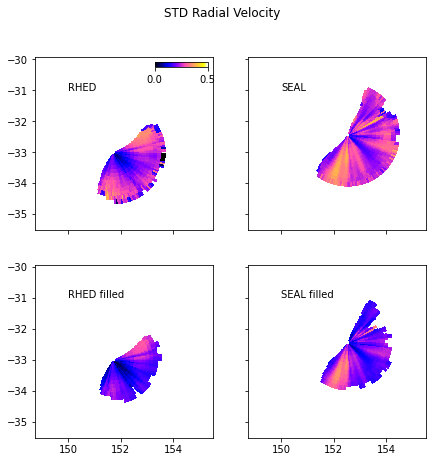

In [162]:
fig,axs=plt.subplots(ncols=2,nrows=2,sharex=True,sharey=True,figsize=(7,7))
pc=axs[0,0].pcolor(rhed_pre['lon'].values,rhed_pre['lat'].values,np.nanmean(rhed_pre['v'].values,axis=0),vmin=-1,vmax=1,cmap='seismic')
axs[1,0].pcolor(rhed_pre['lon'].values,rhed_pre['lat'].values,np.nanmean(rhed_filled['v'].values,axis=0),vmin=-1,vmax=1,cmap='seismic')

axs[0,1].pcolor(seal_pre['lon'].values,seal_pre['lat'].values,np.nanmean(seal_pre['v'].values,axis=0),vmin=-1,vmax=1,cmap='seismic')
axs[1,1].pcolor(seal_pre['lon'].values,seal_pre['lat'].values,np.nanmean(seal_filled['v'].values,axis=0),vmin=-1,vmax=1,cmap='seismic')

axs[0,0].text(150,-31,'RHED')
axs[1,0].text(150,-31,'RHED filled')

axs[0,1].text(150,-31,'SEAL')
axs[1,1].text(150,-31,'SEAL filled')
fig.suptitle('Average Radial Velocity ')

cbaxes = inset_axes(axs[0,0], width="30%", height="3%", loc=1)

fig.colorbar(pc,cax=cbaxes,orientation='horizontal')




fig,axs=plt.subplots(ncols=2,nrows=2,sharex=True,sharey=True,figsize=(7,7))
pc=axs[0,0].pcolor(rhed_pre['lon'].values,rhed_pre['lat'].values,np.nanstd(rhed_pre['v'].values,axis=0),vmin=0,vmax=.5,cmap='gnuplot2')
axs[1,0].pcolor(rhed_pre['lon'].values,rhed_pre['lat'].values,np.nanstd(rhed_filled['v'].values,axis=0),vmin=0,vmax=.5,cmap='gnuplot2')

axs[0,1].pcolor(seal_pre['lon'].values,seal_pre['lat'].values,np.nanstd(seal_pre['v'].values,axis=0),vmin=0,vmax=.5,cmap='gnuplot2')
axs[1,1].pcolor(seal_pre['lon'].values,seal_pre['lat'].values,np.nanstd(seal_filled['v'].values,axis=0),vmin=0,vmax=.5,cmap='gnuplot2')

axs[0,0].text(150,-31,'RHED')
axs[1,0].text(150,-31,'RHED filled')

axs[0,1].text(150,-31,'SEAL')
axs[1,1].text(150,-31,'SEAL filled')
fig.suptitle('STD Radial Velocity ')

cbaxes = inset_axes(axs[0,0], width="30%", height="3%", loc=1)

fig.colorbar(pc,cax=cbaxes,orientation='horizontal')


In [184]:
indices_one = np.where(missing_one==1)
indices_two = np.where(missing==0)

Comparing for two radial missing does not look too bad, seems pretty good. Probably because holes are not too long. Also, the smoothing on existing radials seems useful

Text(0.5, 1.0, 'indices when 0 radial (looking for paliers)')

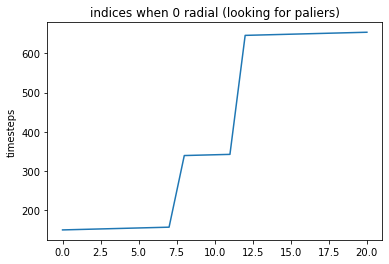

In [220]:
plt.plot(indices_two[0])
plt.ylabel("timesteps")
plt.title('indices when 0 radial (looking for paliers)')

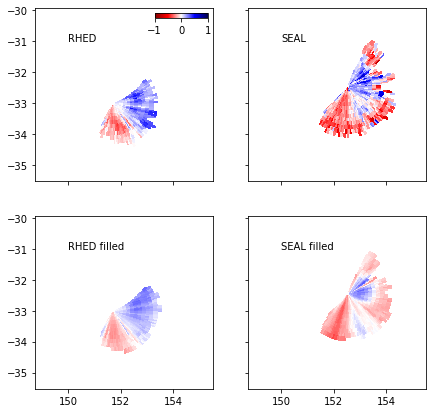

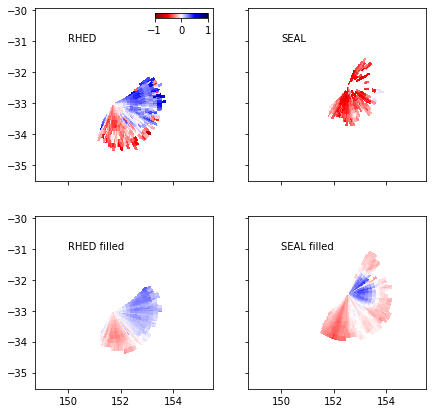

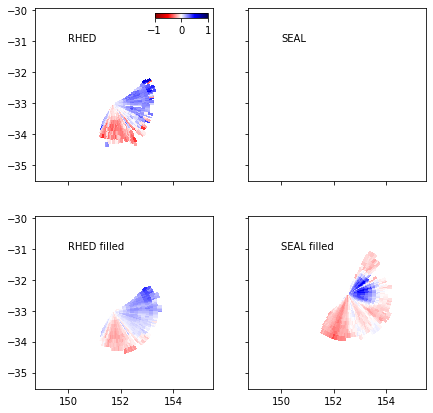

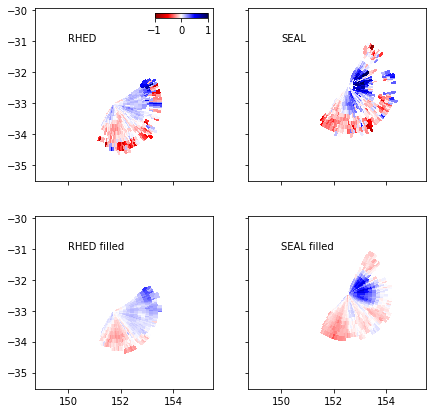

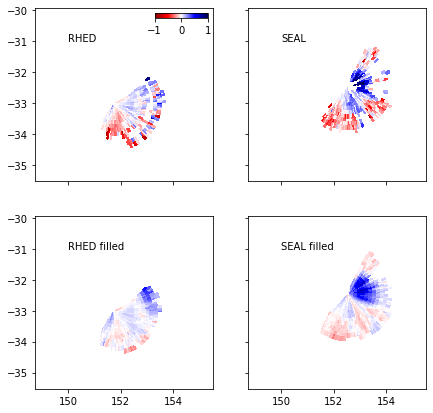

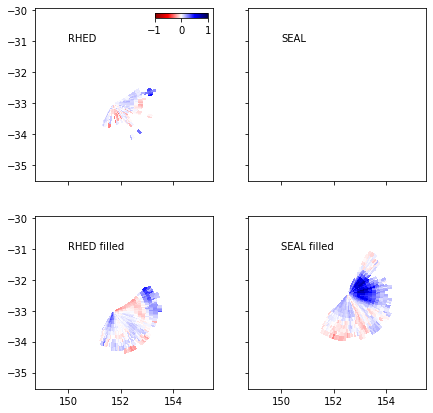

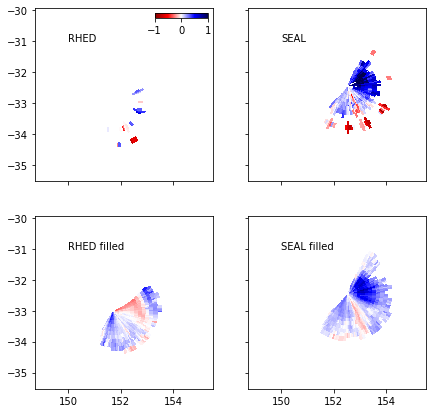

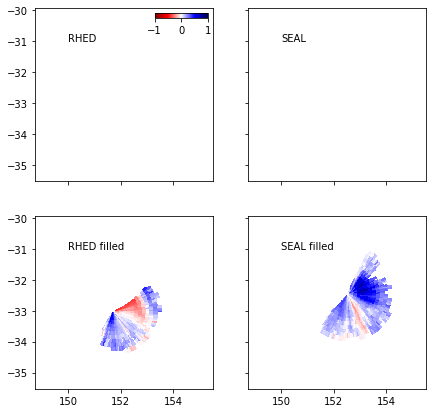

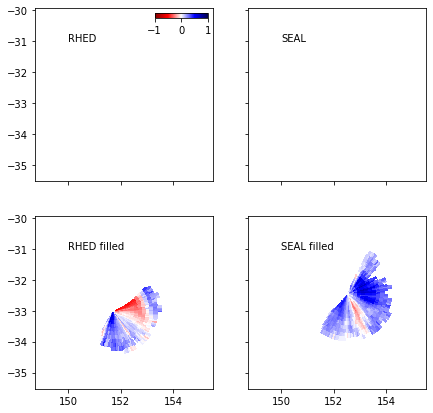

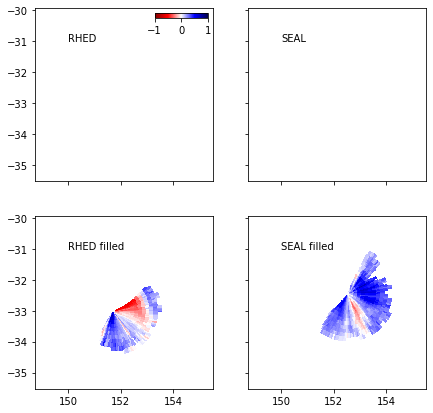

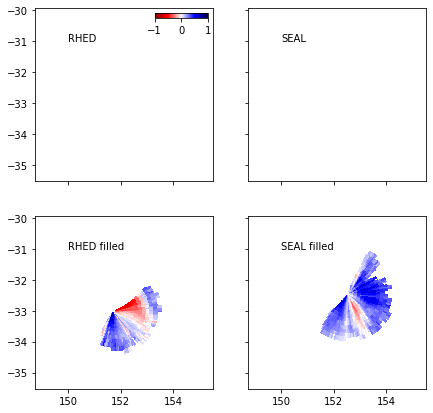

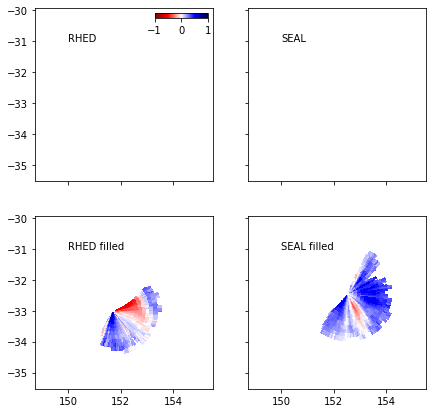

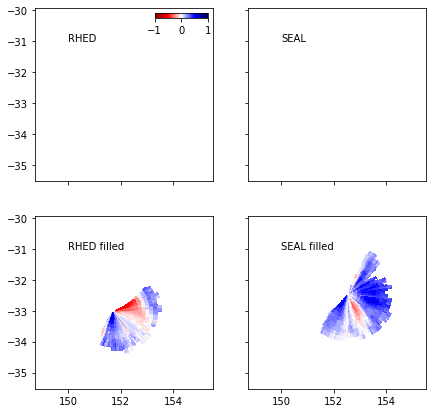

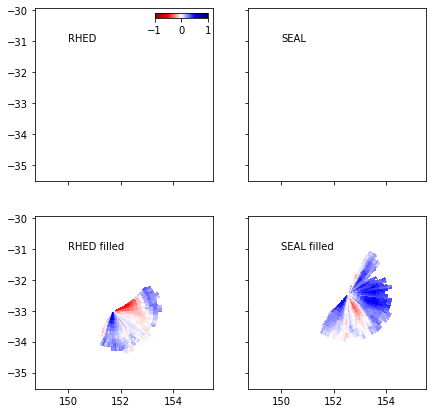

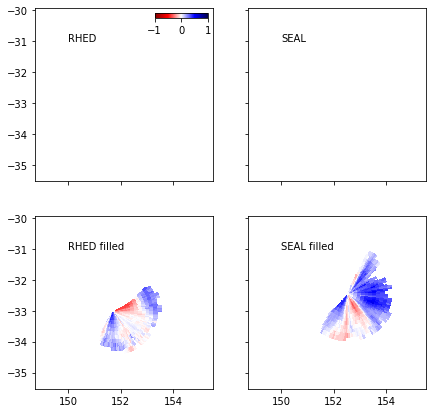

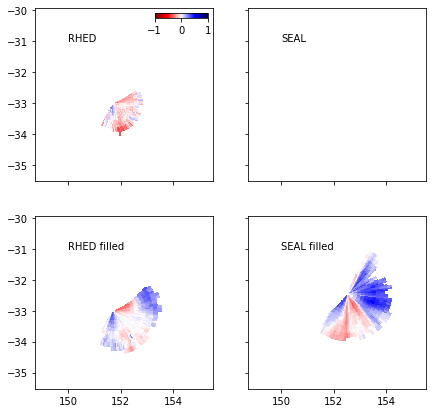

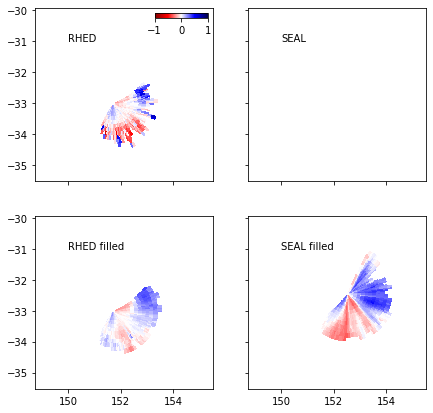

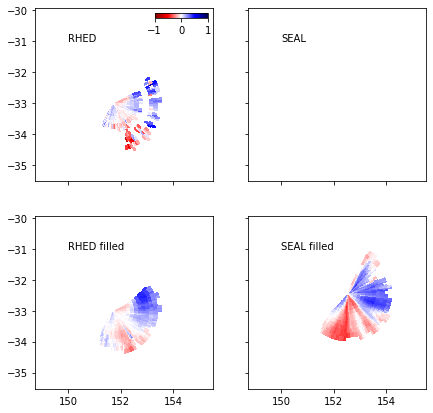

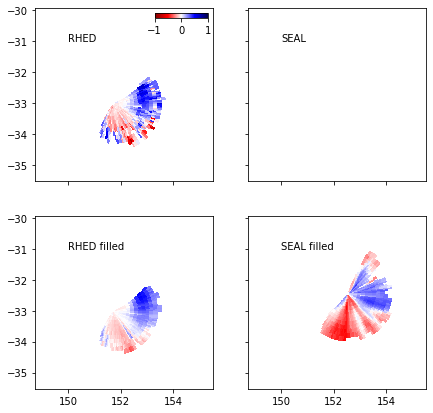

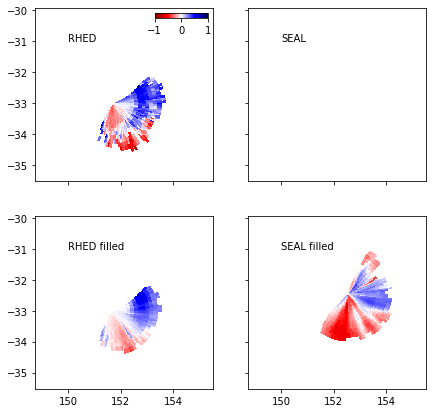

In [196]:
for i in range(-10,10):
    ts = indices_two[0][3]+i

    fig,axs=plt.subplots(ncols=2,nrows=2,sharex=True,sharey=True,figsize=(7,7))
    pc=axs[0,0].pcolor(rhed_pre['lon'].values,rhed_pre['lat'].values,rhed_pre['v'][ts],vmin=-1,vmax=1,cmap='seismic_r')
    axs[1,0].pcolor(rhed_pre['lon'].values,rhed_pre['lat'].values,rhed_filled['v'][ts],vmin=-1,vmax=1,cmap='seismic_r')

    axs[0,1].pcolor(seal_pre['lon'].values,seal_pre['lat'].values,seal_pre['v'][ts],vmin=-1,vmax=1,cmap='seismic_r')
    axs[1,1].pcolor(seal_pre['lon'].values,seal_pre['lat'].values,seal_filled['v'][ts],vmin=-1,vmax=1,cmap='seismic_r')

    axs[0,0].text(150,-31,'RHED')
    axs[1,0].text(150,-31,'RHED filled')

    axs[0,1].text(150,-31,'SEAL')
    axs[1,1].text(150,-31,'SEAL filled')

    cbaxes = inset_axes(axs[0,0], width="30%", height="3%", loc=1)

    fig.colorbar(pc,cax=cbaxes,orientation='horizontal')

Text(0.5, 1.0, 'indices when only one radial (look for paliers)')

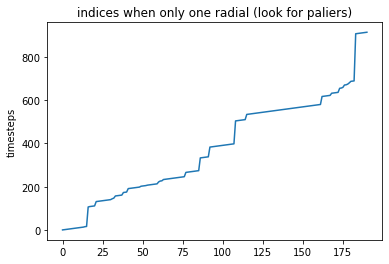

In [219]:
plt.plot(indices_one[0])
plt.ylabel("timesteps")
plt.title('indices when only one radial (looking for paliers)')

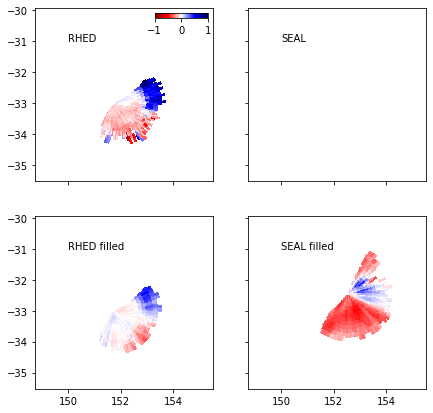

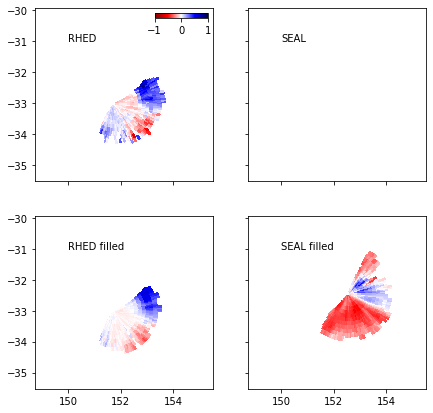

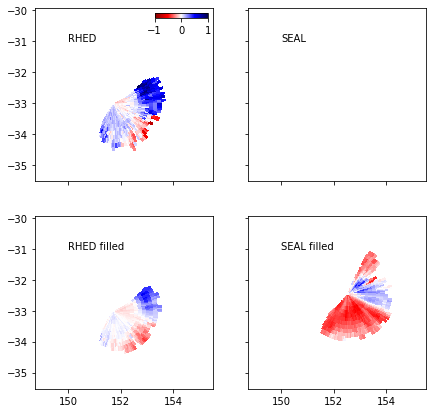

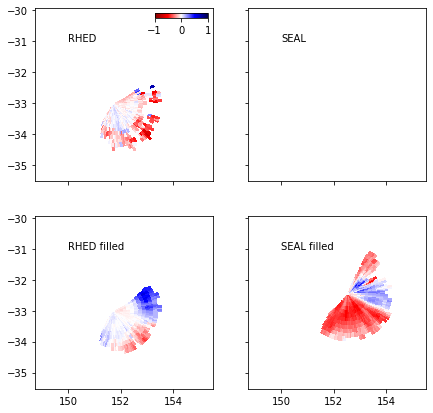

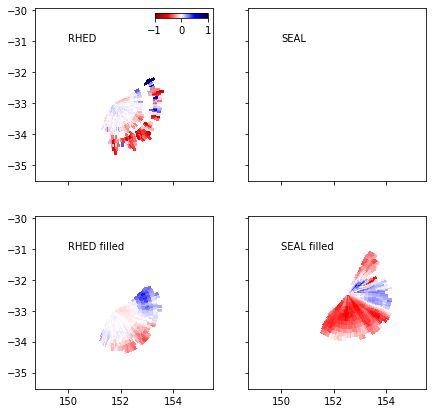

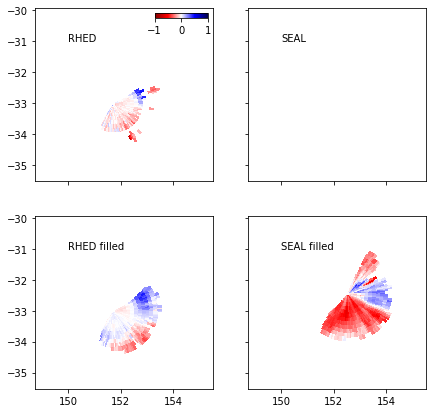

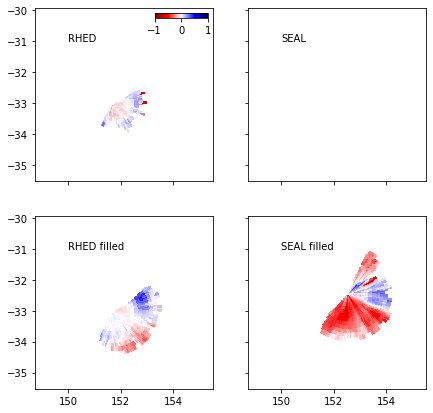

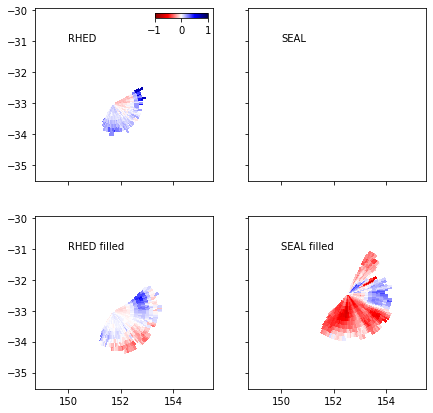

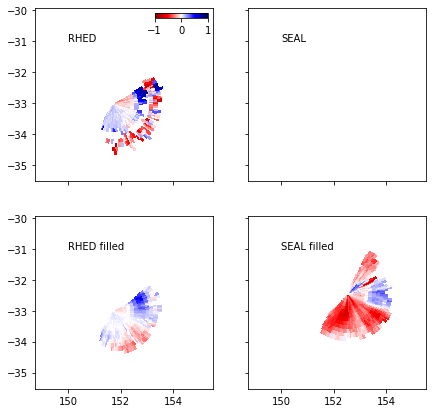

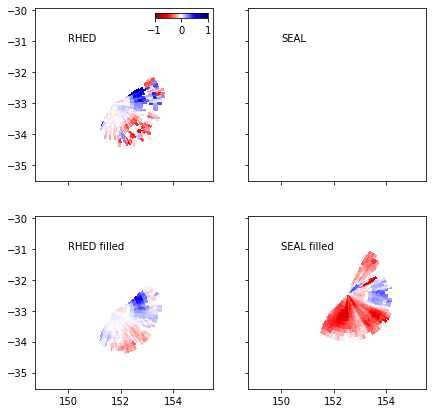

In [193]:
for i in range(-5,5):
    ts = indices_one[0][125]+i

    fig,axs=plt.subplots(ncols=2,nrows=2,sharex=True,sharey=True,figsize=(7,7))
    pc=axs[0,0].pcolor(rhed_pre['lon'].values,rhed_pre['lat'].values,rhed_pre['v'][ts],vmin=-1,vmax=1,cmap='seismic_r')
    axs[1,0].pcolor(rhed_pre['lon'].values,rhed_pre['lat'].values,rhed_filled['v'][ts],vmin=-1,vmax=1,cmap='seismic_r')

    axs[0,1].pcolor(seal_pre['lon'].values,seal_pre['lat'].values,seal_pre['v'][ts],vmin=-1,vmax=1,cmap='seismic_r')
    axs[1,1].pcolor(seal_pre['lon'].values,seal_pre['lat'].values,seal_filled['v'][ts],vmin=-1,vmax=1,cmap='seismic_r')

    axs[0,0].text(150,-31,'RHED')
    axs[1,0].text(150,-31,'RHED filled')

    axs[0,1].text(150,-31,'SEAL')
    axs[1,1].text(150,-31,'SEAL filled')

    cbaxes = inset_axes(axs[0,0], width="30%", height="3%", loc=1)

    fig.colorbar(pc,cax=cbaxes,orientation='horizontal')

---

# Conclusion : DINEOF does a good job at filling and smoothing non-empty maps. Does a good job on short periods of missing maps. 

-> **We need to define a threshold of missing maps over which we delete the data.**


-> **We need to create a mask (on SEAL) because data is weird at the north of the domain**


### Define bad timesteps
We have to remove the beginning where SEAL is missing and there is no data before

In [261]:
indices_two

(array([149, 150, 151, 152, 153, 154, 155, 156, 339, 340, 341, 342, 646,
        647, 648, 649, 650, 651, 652, 653, 654]),)

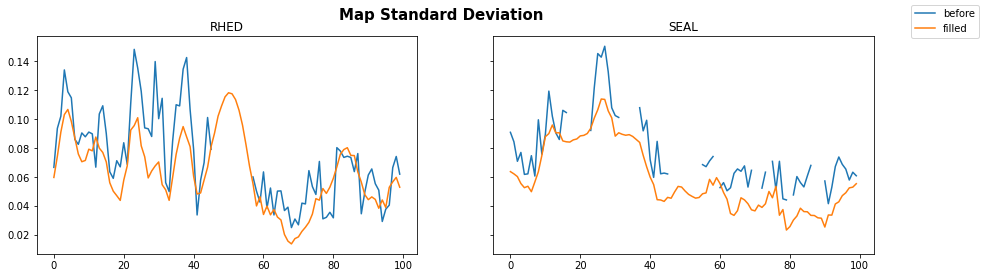

In [265]:
t0=600
t1=700
fig,axs=plt.subplots(ncols=2,nrows=1,sharex=True,sharey=True,figsize=(15,4))
axs[0].title.set_text('RHED')
axs[0].plot(np.nanstd(np.nanstd(rhed_pre['v'][t0:t1,:,:],axis=2),axis=1),label='before')
axs[0].plot(np.nanstd(np.nanstd(rhed_filled['v'][t0:t1,:,:],axis=2),axis=1),label='filled')
fig.suptitle('Map Standard Deviation',fontweight='bold',fontsize=15)

axs[1].title.set_text('SEAL')
axs[1].plot(np.nanstd(np.nanstd(seal_pre['v'][t0:t1,:,:],axis=2),axis=1))
axs[1].plot(np.nanstd(np.nanstd(seal_filled['v'][t0:t1,:,:],axis=2),axis=1))
fig.legend()

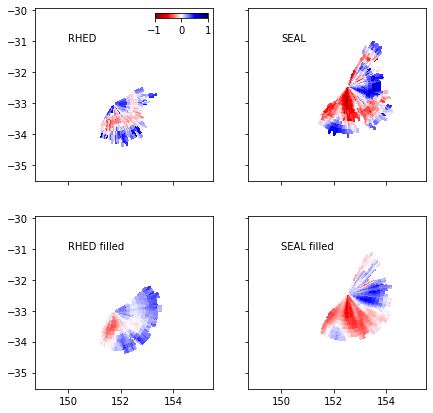

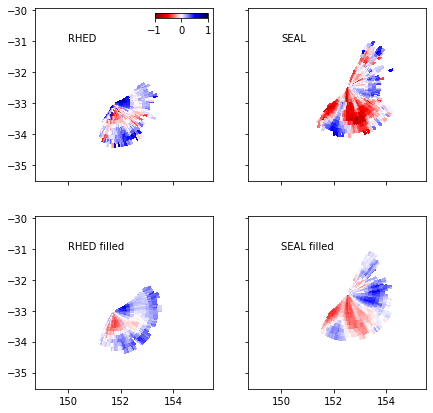

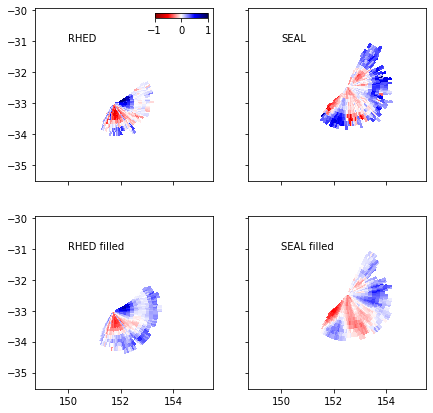

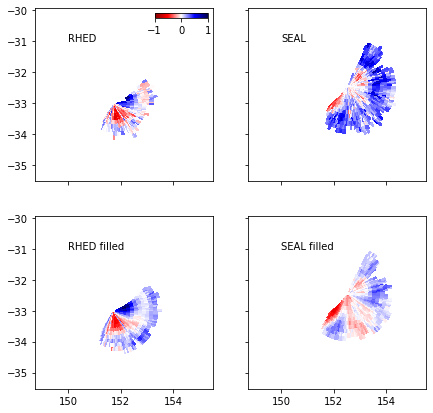

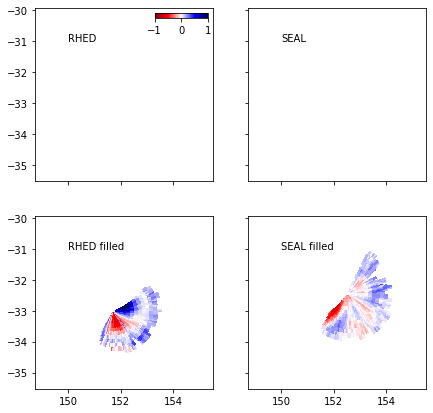

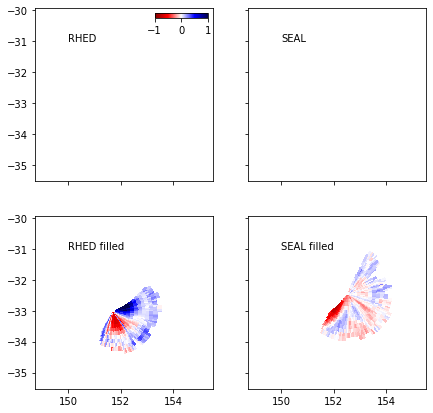

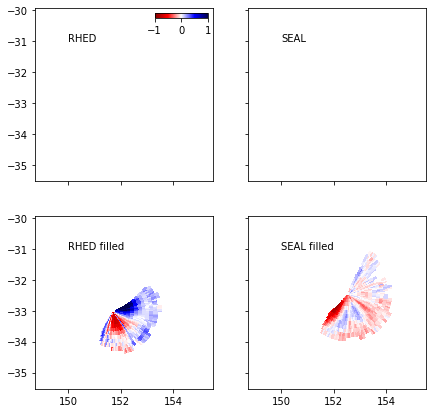

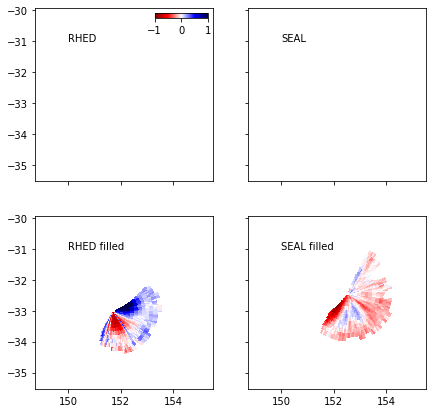

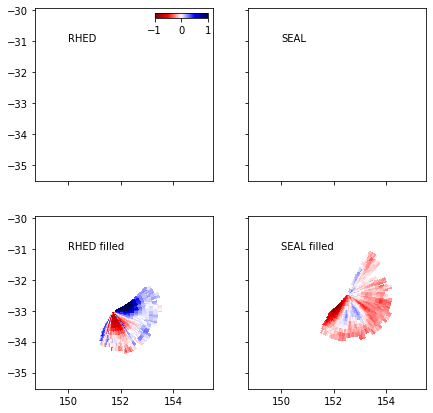

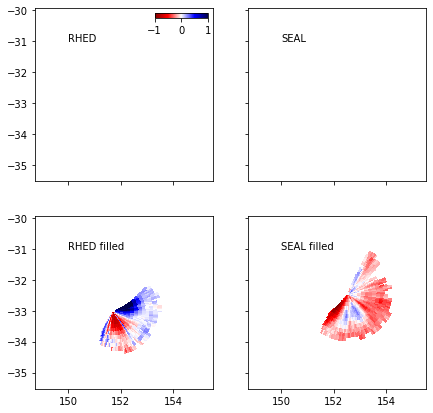

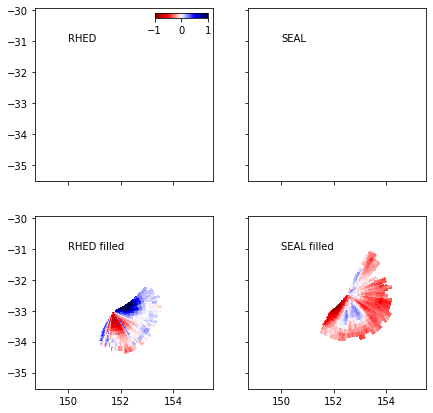

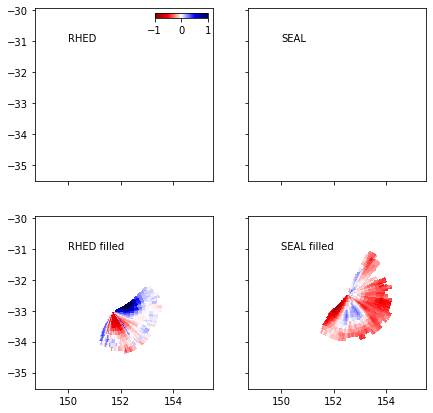

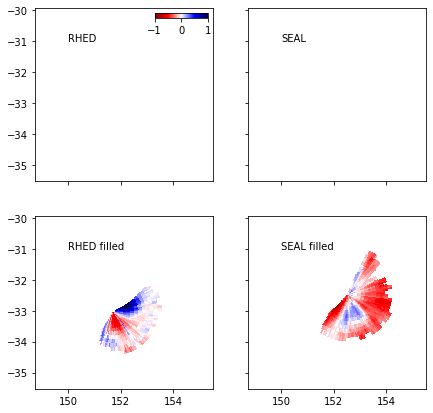

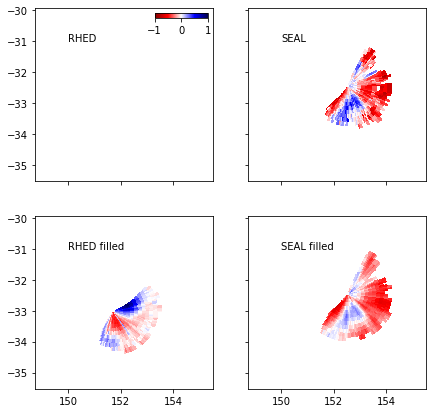

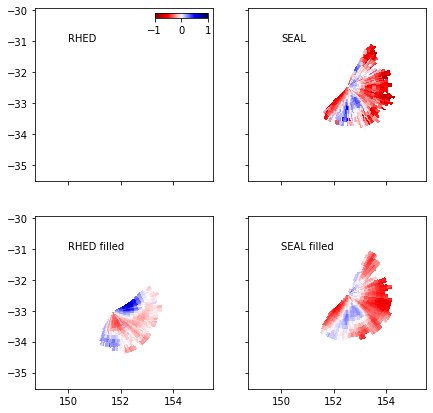

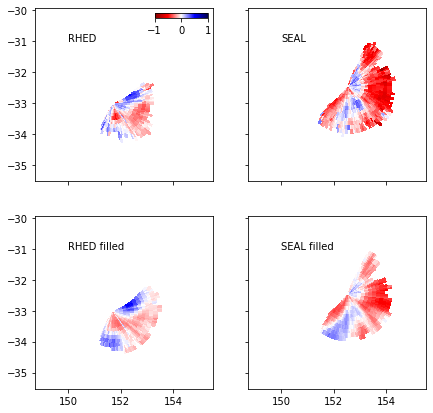

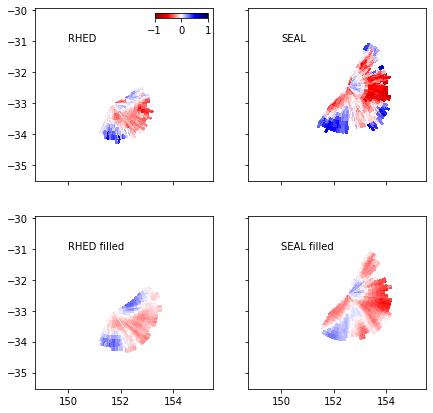

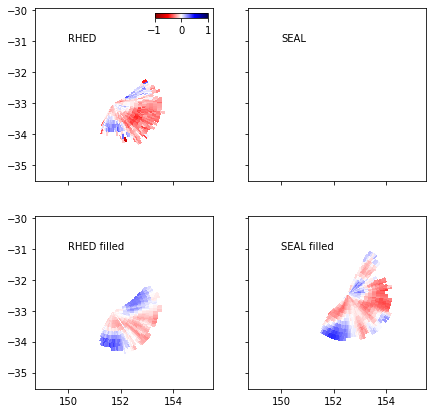

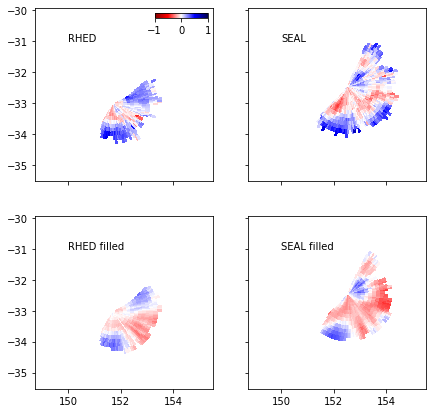

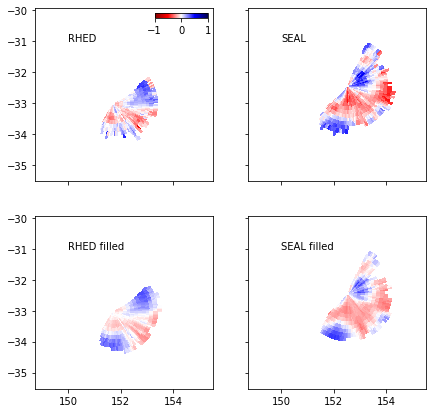

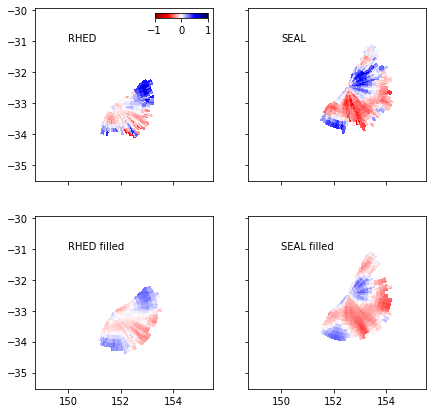

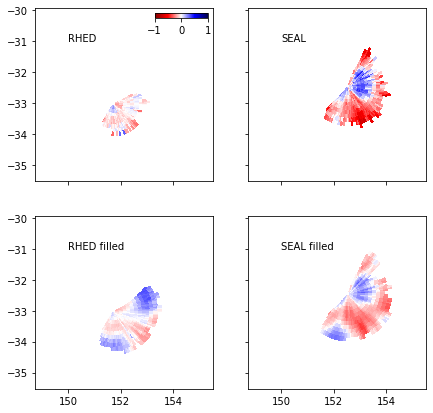

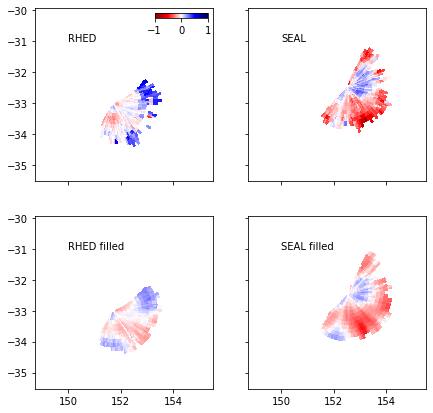

In [273]:
for ts in range(642,665):

    fig,axs=plt.subplots(ncols=2,nrows=2,sharex=True,sharey=True,figsize=(7,7))
    pc=axs[0,0].pcolor(rhed_pre['lon'].values,rhed_pre['lat'].values,rhed_pre['v'][ts],vmin=-1,vmax=1,cmap='seismic_r')
    axs[1,0].pcolor(rhed_pre['lon'].values,rhed_pre['lat'].values,rhed_filled['v'][ts],vmin=-1,vmax=1,cmap='seismic_r')

    axs[0,1].pcolor(seal_pre['lon'].values,seal_pre['lat'].values,seal_pre['v'][ts],vmin=-1,vmax=1,cmap='seismic_r')
    axs[1,1].pcolor(seal_pre['lon'].values,seal_pre['lat'].values,seal_filled['v'][ts],vmin=-1,vmax=1,cmap='seismic_r')

    axs[0,0].text(150,-31,'RHED')
    axs[1,0].text(150,-31,'RHED filled')

    axs[0,1].text(150,-31,'SEAL')
    axs[1,1].text(150,-31,'SEAL filled')

    cbaxes = inset_axes(axs[0,0], width="30%", height="3%", loc=1)

    fig.colorbar(pc,cax=cbaxes,orientation='horizontal')


The weird rotation thing very close to the coast is 'reproduced' by DINEOF but it is originally present in the real data from RHED. And is also in the Quality Controlled vectorial data from thredds.

**Might be intensified in the gap-filling but the pattern is still here**

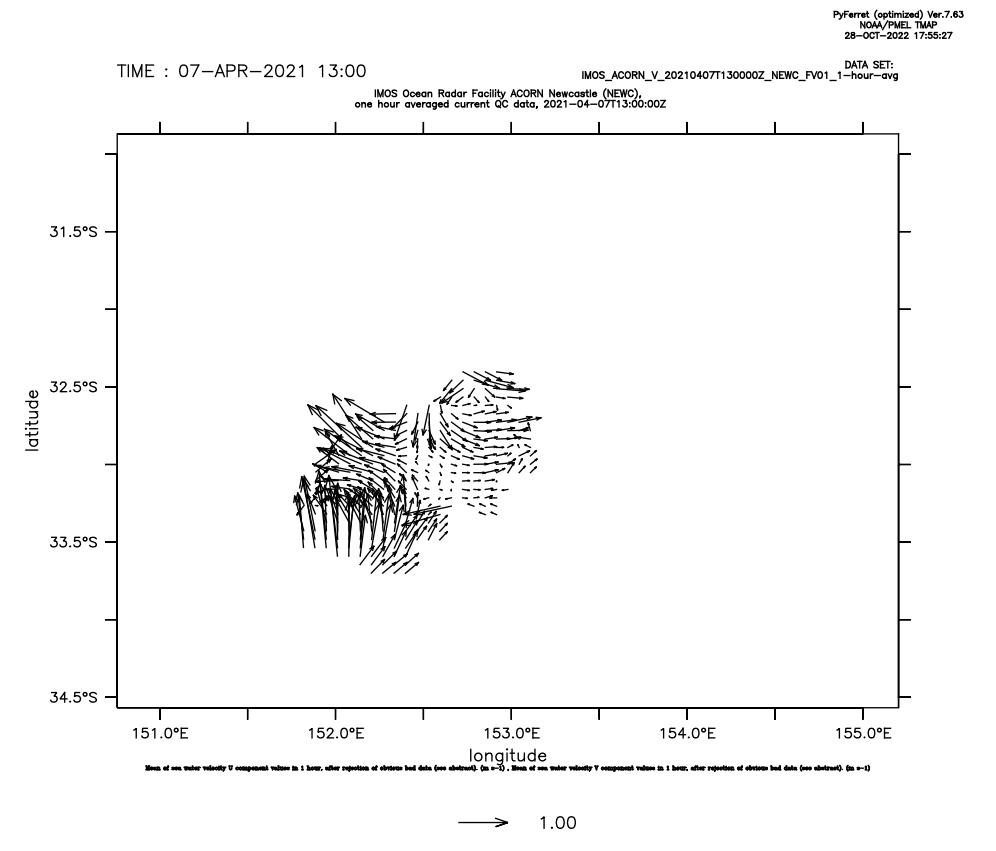

### Redefine Masks

We want to remove things too close to the coast (but not too much), i dont know what im doing

Le petit croc dans la couverture temporelle (156.5E, 32S) c'est le QC qui a enlevé bcp de données là bas parce que c'était souvent pourri

(-35.0, -30.5)

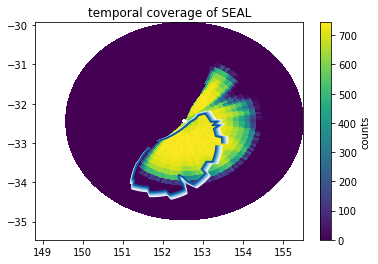

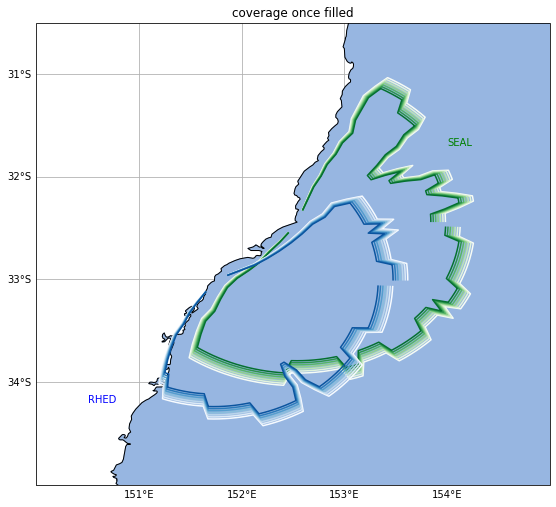

In [312]:
plt.pcolor(seal_pre['lon'].values,seal_pre['lat'].values,get_pixel_coverage(seal_pre['v'].values))
plt.title('temporal coverage of SEAL')
plt.colorbar(label='counts')
plt.contour(rhed_pre['lon'].values,rhed_pre['lat'].values,get_pixel_coverage(rhed_filled['v'].values),
            label='RHED',cmap='Blues')


fig,ax=fig_cot_au(1,1)
ax.title.set_text('coverage once filled')
cf=ax.contour(seal_pre['lon'].values,seal_pre['lat'].values,get_pixel_coverage(seal_filled['v'].values),
            label='SEAL',cmap='Greens')
cf=ax.contour(rhed_pre['lon'].values,rhed_pre['lat'].values,get_pixel_coverage(rhed_filled['v'].values),
            label='RHED',cmap='Blues')
ax.text(150.5,-34.2,'RHED',color='blue')
ax.text(154,-31.7,'SEAL',color='green')
ax.set_xlim(150,155)
ax.set_ylim(-35,-30.5)

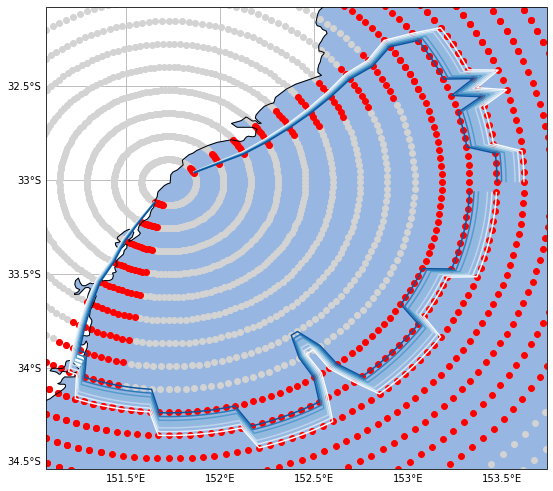

In [374]:
xmin = 120
xmax = 130

xmin2 = 12
xmax2 = 20

ymin = 9
ymax = 16

fig,ax=fig_cot_au(1,1)
ax.scatter(rhed_pre['lon'].values,rhed_pre['lat'].values,c='lightgrey')

ax.scatter(rhed_pre['lon'][xmin:xmax,:].values,rhed_pre['lat'][xmin:xmax,:].values,c='r')
ax.scatter(rhed_pre['lon'][xmin2:xmax2,:].values,rhed_pre['lat'][xmin2:xmax2,:].values,c='r')
ax.scatter(rhed_pre['lon'][:,ymin:ymax].values,rhed_pre['lat'][:,ymin:ymax].values,c='r')

ax.contour(rhed_pre['lon'].values,rhed_pre['lat'].values,get_pixel_coverage(rhed_filled['v'].values),
           cmap='Blues')

mask_rhed = np.ones((rhed_pre['lon'].values).shape)
mask_rhed[xmin:xmax,:]=np.nan
mask_rhed[xmin2:xmax2,:]=np.nan
mask_rhed[:,ymin:ymax]=np.nan

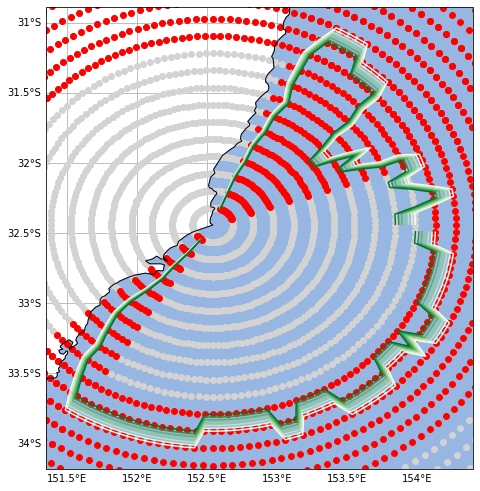

In [360]:
xmin = 110
xmax = 120

xmin2 = 10
xmax2= 35

ymin = 10
ymax = 16

fig,ax=fig_cot_au(1,1)
ax.scatter(seal_pre['lon'].values,seal_pre['lat'].values,c='lightgrey')
ax.scatter(seal_pre['lon'][xmin:xmax,:].values,seal_pre['lat'][xmin:xmax,:].values,c='r')

ax.scatter(seal_pre['lon'][xmin2:xmax2,:].values,seal_pre['lat'][xmin2:xmax2,:].values,c='r')
ax.scatter(seal_pre['lon'][:,ymin:ymax].values,seal_pre['lat'][:,ymin:ymax].values,c='r')

ax.contour(seal_pre['lon'].values,seal_pre['lat'].values,get_pixel_coverage(seal_filled['v'].values),
           cmap='Greens')

mask_seal = np.ones((seal_pre['lon'].values).shape)
mask_seal[xmin:xmax,:]=np.nan
mask_seal[xmin2:xmax2,:]=np.nan
mask_seal[:,ymin:ymax]=np.nan

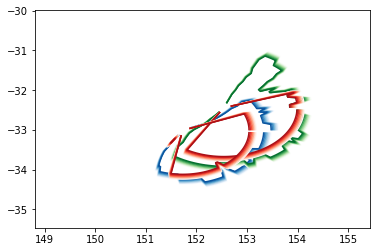

In [375]:

plt.contour(seal_pre['lon'].values,seal_pre['lat'].values,get_pixel_coverage(seal_filled['v'].values),
           cmap='Greens',zorder=3)
plt.contour(seal_pre['lon'].values,seal_pre['lat'].values,get_pixel_coverage(seal_filled['v'].values*mask_seal),
           cmap='Reds',zorder=4)


plt.contour(rhed_pre['lon'].values,rhed_pre['lat'].values,get_pixel_coverage(rhed_filled['v'].values),
           cmap='Blues',zorder=0)
plt.contour(rhed_pre['lon'].values,rhed_pre['lat'].values,get_pixel_coverage(rhed_filled['v'].values*mask_rhed),
           cmap='Reds',zorder=5)